In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
cic_data=pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [3]:
cic_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
cic_data.shape

(225745, 79)

In [5]:
cic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [6]:
cic_data.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [7]:
cic_data = cic_data.dropna()

In [8]:
cic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225741 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225741 non-null  int64  
 1    Flow Duration                225741 non-null  int64  
 2    Total Fwd Packets            225741 non-null  int64  
 3    Total Backward Packets       225741 non-null  int64  
 4   Total Length of Fwd Packets   225741 non-null  int64  
 5    Total Length of Bwd Packets  225741 non-null  int64  
 6    Fwd Packet Length Max        225741 non-null  int64  
 7    Fwd Packet Length Min        225741 non-null  int64  
 8    Fwd Packet Length Mean       225741 non-null  float64
 9    Fwd Packet Length Std        225741 non-null  float64
 10  Bwd Packet Length Max         225741 non-null  int64  
 11   Bwd Packet Length Min        225741 non-null  int64  
 12   Bwd Packet Length Mean       225741 non-null  fl

In [9]:
cic_data.duplicated().sum()

np.int64(2633)

In [10]:
cic_data = cic_data.drop_duplicates()

In [11]:
cic_data.columns = cic_data.columns.str.strip()

In [12]:
cic_data['Label'] = cic_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [13]:
X = cic_data.drop('Label', axis=1)
y = cic_data['Label']

In [14]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

In [15]:
selector = VarianceThreshold(threshold=0)
X = selector.fit_transform(X)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_scaled = np.nan_to_num(X_scaled)

In [18]:
pca = PCA(n_components=20)  # adjust based on explained variance
X_pca = pca.fit_transform(X_scaled)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Decision Tree

In [20]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# XGBoost

In [22]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# Model Evaluation

In [23]:
def evaluate_model(model):
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [24]:
evaluate_model(dt)

Accuracy: 0.9997758952982834

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19019
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622


Confusion Matrix:
 [[19013     6]
 [    4 25599]]


In [25]:
evaluate_model(rf)

Accuracy: 0.99986553717897

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19019
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622


Confusion Matrix:
 [[19019     0]
 [    6 25597]]


In [26]:
evaluate_model(xgb)

Accuracy: 0.9999103581193134

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19019
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622


Confusion Matrix:
 [[19019     0]
 [    4 25599]]


In [27]:
y_prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

0.9999604902792646

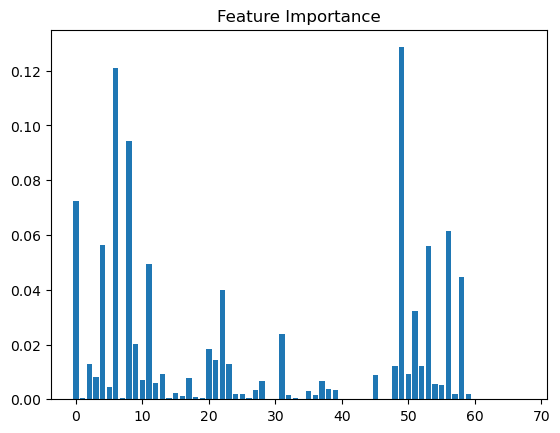

In [28]:
importances = rf.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()